In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn scipy -q

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import LinearSVR
from sklearn.base import clone

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## 2. User Input

In [ ]:
default_lat  = 16.49
default_lon  = 80.49
default_date = '2026-03-14'

Shape: (5956, 10)
                       date  temp_mean  temp_max  temp_min  humidity_mean  \
0 2010-01-01 00:00:00+00:00  24.942417   30.6695   19.8195      70.269077   
1 2010-01-02 00:00:00+00:00  24.525750   29.2695   19.5695      69.573887   
2 2010-01-03 00:00:00+00:00  24.111167   29.0195   19.4195      69.499383   
3 2010-01-04 00:00:00+00:00  24.261167   29.5195   19.7695      69.981235   
4 2010-01-05 00:00:00+00:00  24.907000   31.6695   19.5195      70.182977   

   precipitation_sum  wind_speed_mean  wind_speed_max  pressure_mean  \
0                0.0         6.481316       10.464797    1010.873797   
1                0.0         6.238883       11.525623    1012.411951   
2                0.0         4.792703        8.427383    1011.535487   
3                0.0         4.160667        8.854829    1009.375871   
4                0.0         5.610249       12.538134    1008.305125   

   cloud_cover_mean  
0         11.000000  
1         42.708333  
2         17.666667 

## 3. Data Acquisition

In [ ]:
df = pd.read_csv('final_daily_weather (1).csv')
df.ffill(inplace=True)
print(f'Shape before outlier removal: {df.shape}')
print(df.head())
print('\nColumn dtypes:')
print(df.dtypes)

Shape before outlier removal: (5956, 10)
                        date  temp_mean  temp_max  temp_min  humidity_mean  \
0  2010-01-01 00:00:00+00:00  24.942417   30.6695   19.8195      70.269077   
1  2010-01-02 00:00:00+00:00  24.525750   29.2695   19.5695      69.573887   
2  2010-01-03 00:00:00+00:00  24.111167   29.0195   19.4195      69.499383   
3  2010-01-04 00:00:00+00:00  24.261167   29.5195   19.7695      69.981235   
4  2010-01-05 00:00:00+00:00  24.907000   31.6695   19.5195      70.182977   

   precipitation_sum  wind_speed_mean  wind_speed_max  pressure_mean  \
0                0.0         6.481316       10.464797    1010.873797   
1                0.0         6.238883       11.525623    1012.411951   
2                0.0         4.792703        8.427383    1011.535487   
3                0.0         4.160667        8.854829    1009.375871   
4                0.0         5.610249       12.538134    1008.305125   

   cloud_cover_mean  
0         11.000000  
1         42.

## 4. Preprocessing & Outlier Handling

**Fix applied:** Outliers are removed per-column independently (not row-wise chained),
which avoids excessive data loss and removes the most extreme values safely.

In [ ]:
targets = ['temp_mean', 'temp_min', 'temp_max',
           'humidity_mean', 'precipitation_sum', 'wind_speed_mean', 'pressure_mean']

# Remove outliers per column independently
df_clean = df.copy()
for var in targets:
    z_scores = np.abs(stats.zscore(df_clean[[var]]))
    df_clean = df_clean[(z_scores <= 3).flatten()]

print(f'\nShape after outlier removal: {df_clean.shape}')


df_clean['precip_log'] = np.log1p(df_clean['precipitation_sum'])
print(f"\nPrecipitation skew (raw):     {df_clean['precipitation_sum'].skew():.3f}")
print(f"Precipitation skew (log1p):   {df_clean['precip_log'].skew():.3f}")

df = df_clean.copy()


Shape after outlier removal: (5747, 10)

Precipitation skew (raw):     2.833
Precipitation skew (log1p):   1.411


## 5. Feature Engineering


In [ ]:
df['date']        = pd.to_datetime(df['date'])
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['day_of_week'] = df['date'].dt.dayofweek

# Cyclical encodings
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']  / 12)
df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['dow_sin']= np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']= np.cos(2 * np.pi * df['day_of_week'] / 7)

base_features = ['year', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'day_of_year']

# ── Lag configuration ───────────────────────────────────────────────────────
cols_to_lag_all   = ['temp_mean', 'temp_min', 'temp_max', 'humidity_mean',
                     'precipitation_sum', 'wind_speed_mean', 'pressure_mean', 'precip_log']
lags              = [2, 3, 7, 14]
rolling_windows   = [3, 7, 14]

features = base_features.copy()
for p in cols_to_lag_all:
    for lag in lags:
        col_name        = f'{p}_lag_{lag}'
        df[col_name]    = df[p].shift(lag)
        features.append(col_name)
    for window in rolling_windows:
        col_name        = f'{p}_rolling_mean_{window}'
        df[col_name]    = df[p].shift(2).rolling(window=window).mean()  # shift(2) to match min lag
        features.append(col_name)
df['temp_range']= df['temp_max'] - df['temp_min']
df['temp_range_lag2']= df['temp_range'].shift(2)

# FIXED: .diff(2/3) on raw column uses TODAY's value → direct leakage of target
# Safe version: shift first so diffs are computed entirely in the past
df['pressure_diff2'] = df['pressure_mean'].shift(2).diff(1)  # day[t-2] - day[t-3]
df['pressure_diff3'] = df['pressure_mean'].shift(3).diff(1)  # day[t-3] - day[t-4]

df['humidity_lag1']= df['humidity_mean'].shift(1)
df['press_temp_interaction'] = df['pressure_mean'].shift(2) * df['temp_mean'].shift(2)

df['precip_lag1']= df['precipitation_sum'].shift(1)  # lag1 OK for precip (low autocorr)
df['precip_log_lag1'] = df['precip_log'].shift(1)
df['wet_day_lag1']= (df['precipitation_sum'].shift(1) > 1.0).astype(int)

interaction_features = [
    'temp_range', 'temp_range_lag2',
    'pressure_diff2', 'pressure_diff3',
    'press_temp_interaction',
    'humidity_lag1',
    'precip_lag1', 'precip_log_lag1', 'wet_day_lag1',
]
features += interaction_features

df.dropna(inplace=True)
print(f'Final shape: {df.shape} | Total features: {len(features)}')

# Verify no more perfect correlations
print("\n=== Autocorrelation check (should NOT be close to 1.0 for temp/pressure) ===")
for t in ['temp_mean', 'pressure_mean', 'humidity_mean', 'precipitation_sum']:
    lag2_col = f'{t}_lag_2'
    if lag2_col in df.columns:
        corr = df[lag2_col].corr(df[t])
        print(f'  {lag2_col} → {t}: {corr:.4f}')

Final shape: (5732, 86) | Total features: 73

=== Autocorrelation check (should NOT be close to 1.0 for temp/pressure) ===
  temp_mean_lag_2 → temp_mean: 0.9158
  pressure_mean_lag_2 → pressure_mean: 0.9300
  humidity_mean_lag_2 → humidity_mean: 0.7247
  precipitation_sum_lag_2 → precipitation_sum: 0.3509


## 6. Train/Test Split & Feature Scaling

In [ ]:
split = int(len(df) * 0.8)

X_all   = df[features]
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_all.iloc[:split])
X_test  = scaler.transform(X_all.iloc[split:])

print(f'Train size: {X_train.shape[0]} rows | Test size: {X_test.shape[0]} rows')
print(f'Features:   {X_train.shape[1]}')

Train size: 4585 rows | Test size: 1147 rows
Features:   73


## 7. Comprehensive Model Comparison Pipeline


In [ ]:
# 7. Comprehensive Model Comparison Pipeline
from sklearn.metrics import mean_squared_error

n_features = X_train.shape[1]
print(f'[Pipeline] Processing {n_features} features')

param_grids = {
    'Ridge Reg': {'alpha': [0.1, 1.0, 10, 100]},
    'Linear Reg': {},
    'Gradient Descent (SGD)': {'alpha': [0.001, 0.01], 'learning_rate': ['adaptive'], 'eta0': [0.01]},
    'Decision Tree': {'max_depth': [3, 5, 7]},
    'Random Forest': {
      'n_estimators': [100, 200, 300],
      'max_depth': [5, 7, 10, None],
      'min_samples_leaf': [5, 10, 20],
      'min_samples_split': [5, 10],
      'max_features': ['sqrt', 'log2']
    },
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]},
    'Gradient Boost': {
      'learning_rate': [0.01, 0.03, 0.05, 0.1],
      'max_iter': [100, 300, 500],
      'max_depth': [3, 5, 8],
      'l2_regularization': [0.0, 0.1, 1.0],
      'max_leaf_nodes': [15, 31, 63]
    },
    'SVR': {'C': [0.1, 1, 10], 'epsilon': [0.1, 0.5]},
}

models = {
    'Ridge Reg': Ridge(),
    'Linear Reg': LinearRegression(),
    'Gradient Descent (SGD)': SGDRegressor(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Gradient Boost': HistGradientBoostingRegressor(random_state=42),
    'SVR': LinearSVR(max_iter=5000, random_state=42),
}

target_mapping = {
    'Temperature Mean': 'temp_mean', 'Temperature Max': 'temp_max',
    'Humidity': 'humidity_mean', 'Precipitation': 'precip_log',
    'Wind Speed': 'wind_speed_mean', 'Pressure': 'pressure_mean',
}

GOOD_FIT_GAP_ABS = 0.05

optimal_models, comparison_reports, optimal_predictions = {}, {}, {}
learning_rate_data = {name: {} for name in target_mapping}   # ← ADDED

for target_name, target_col in target_mapping.items():
    print(f"\n{'-'*60}\n TRAINING FOR: {target_name.upper()}\n{'-'*60}")
    y = df[target_col]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    model_results = []

    for m_name, model in models.items():
        grid = param_grids[m_name].copy()

        if target_col == 'precip_log':
            if m_name == 'Gradient Boost':
                grid['learning_rate'] = [0.1]
                grid['max_iter'] = [500]
                grid['max_depth'] = [10]
            elif m_name == 'Random Forest':
                grid['max_depth'], grid['min_samples_leaf'] = [10, 15], [10, 20]

        if grid:
            search = RandomizedSearchCV(model, grid, n_iter=10, cv=5,
                                        scoring='neg_mean_squared_error',
                                        n_jobs=-1, random_state=42)
            search.fit(X_train, y_train)
            fitted_model = search.best_estimator_
            best_params  = search.best_params_

            # ── Collect LR curve data for Gradient Boost / AdaBoost ──────────
            if 'learning_rate' in grid and len(grid['learning_rate']) > 1:
                cv_res = pd.DataFrame(search.cv_results_)
                if 'param_learning_rate' in cv_res.columns:
                    lr_scores = (
                        cv_res.groupby('param_learning_rate')['mean_test_score']
                        .mean().abs().to_dict()
                    )
                    learning_rate_data[target_name][m_name] = lr_scores  # ← ADDED
        else:
            fitted_model = clone(model).fit(X_train, y_train)
            best_params  = 'Default'

        tr_p, te_p   = fitted_model.predict(X_train), fitted_model.predict(X_test)
        tr_r2, te_r2 = r2_score(y_train, tr_p), r2_score(y_test, te_p)
        tr_rmse      = np.sqrt(mean_squared_error(y_train, tr_p))
        te_rmse      = np.sqrt(mean_squared_error(y_test,  te_p))
        gap          = abs(tr_r2 - te_r2)

        if te_r2 < 0.30:          fit_status = 'Underfit'
        elif gap > 0.12:           fit_status = 'Overfit'
        elif gap <= GOOD_FIT_GAP_ABS: fit_status = 'Good Fit'
        else:                      fit_status = 'Acceptable Fit'

        model_results.append({
            'Algorithm': m_name, 'Train RMSE': tr_rmse, 'Test RMSE': te_rmse,
            'Train R2': tr_r2,   'Test R2': te_r2,      'R2 Gap': gap,
            'Fit Score': te_r2 - (2.0 * gap), 'Fit Status': fit_status,
            'ModelObj': fitted_model, 'Preds': te_p
        })

    report_df  = pd.DataFrame(model_results).sort_values('Fit Score', ascending=False)
    best_row   = report_df.iloc[0]
    optimal_models[target_col]      = best_row['ModelObj']
    comparison_reports[target_name] = report_df
    optimal_predictions[target_col] = {'y_true': y_test, 'y_pred': best_row['Preds']}
    print(f" BEST: {best_row['Algorithm']} (Status: {best_row['Fit Status']} | Test R2: {best_row['Test R2']:.4f})")

[Pipeline] Processing 73 features

------------------------------------------------------------
 TRAINING FOR: TEMPERATURE MEAN
------------------------------------------------------------
 BEST: SVR (Status: Good Fit | Test R2: 0.8857)

------------------------------------------------------------
 TRAINING FOR: TEMPERATURE MAX
------------------------------------------------------------
 BEST: Linear Reg (Status: Good Fit | Test R2: 0.9181)

------------------------------------------------------------
 TRAINING FOR: HUMIDITY
------------------------------------------------------------
 BEST: SVR (Status: Acceptable Fit | Test R2: 0.7503)

------------------------------------------------------------
 TRAINING FOR: PRECIPITATION
------------------------------------------------------------
 BEST: Ridge Reg (Status: Acceptable Fit | Test R2: 0.4711)

------------------------------------------------------------
 TRAINING FOR: WIND SPEED
-----------------------------------------------------

## 8. Model Comparison Report

In [ ]:
for target_name, report_df in comparison_reports.items():
    print(f'\n=== {target_name} Algorithm Rankings ===')

    # Selecting relevant columns for display
    cols = ['Algorithm', 'Train RMSE', 'Test RMSE', 'Train R2', 'Test R2', 'R2 Gap', 'Fit Score', 'Fit Status']

    formatted = report_df[cols].copy()

    # Formatting numbers for clear display
    num_cols = ['Train RMSE', 'Test RMSE', 'Train R2', 'Test R2', 'R2 Gap', 'Fit Score']
    for col in num_cols:
        formatted[col] = formatted[col].apply(lambda x: f'{x:.4f}')

    display(formatted)

    best = report_df.iloc[0]
    print(f"  → Best model : {best['Algorithm']}")
    print(f"Fit Status : {best['Fit Status']}")
    print(f"Test R²: {best['Test R2']:.4f}| Test RMSE: {best['Test RMSE']:.4f}")


=== Temperature Mean Algorithm Rankings ===


,Algorithm,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap,Fit Score,Fit Status
7,SVR,0.8811,0.9113,0.9132,0.8857,0.0275,0.8307,Good Fit
1,Linear Reg,0.8723,0.9082,0.9149,0.8865,0.0284,0.8296,Good Fit
2,Gradient Descent (SGD),0.8790,0.9133,0.9136,0.8852,0.0284,0.8284,Good Fit
0,Ridge Reg,0.8757,0.9129,0.9142,0.8853,0.0289,0.8275,Good Fit
6,Gradient Boost,0.4796,0.8655,0.9743,0.8969,0.0774,0.7422,Acceptable Fit
4,Random Forest,0.7034,0.9802,0.9447,0.8677,0.0769,0.7139,Acceptable Fit
5,AdaBoost,0.9668,1.1139,0.8955,0.8292,0.0662,0.6968,Acceptable Fit
3,Decision Tree,0.7594,1.0973,0.9355,0.8343,0.1012,0.6318,Acceptable Fit


  → Best model : SVR
     Fit Status : Good Fit
     Test R²    : 0.8857   |   Test RMSE: 0.9113

=== Temperature Max Algorithm Rankings ===


,Algorithm,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap,Fit Score,Fit Status
1,Linear Reg,0.9017,0.9475,0.9383,0.9181,0.0202,0.8776,Good Fit
0,Ridge Reg,0.9076,0.9519,0.9375,0.9173,0.0202,0.8769,Good Fit
7,SVR,0.9165,0.9573,0.9363,0.9164,0.0199,0.8766,Good Fit
2,Gradient Descent (SGD),0.9121,0.9551,0.9369,0.9168,0.0201,0.8765,Good Fit
6,Gradient Boost,0.4889,0.9386,0.9819,0.9196,0.0622,0.7951,Acceptable Fit
3,Decision Tree,0.9252,1.3170,0.9351,0.8417,0.0933,0.6551,Acceptable Fit
5,AdaBoost,1.1948,1.4793,0.8917,0.8003,0.0914,0.6175,Acceptable Fit
4,Random Forest,0.8893,1.3770,0.9400,0.8270,0.1130,0.6009,Acceptable Fit


  → Best model : Linear Reg
     Fit Status : Good Fit
     Test R²    : 0.9181   |   Test RMSE: 0.9475

=== Humidity Algorithm Rankings ===


...

  → Best model : Ridge Reg
     Fit Status : Acceptable Fit
     Test R²    : 0.4711   |   Test RMSE: 0.6786

=== Wind Speed Algorithm Rankings ===


,Algorithm,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap,Fit Score,Fit Status
7,SVR,1.9843,2.1550,0.4941,0.4235,0.0706,0.2823,Acceptable Fit
2,Gradient Descent (SGD),1.9738,2.1571,0.4994,0.4223,0.0771,0.2682,Acceptable Fit
0,Ridge Reg,1.9779,2.1598,0.4974,0.4209,0.0765,0.2679,Acceptable Fit
1,Linear Reg,1.9668,2.1573,0.5030,0.4222,0.0808,0.2607,Acceptable Fit
5,AdaBoost,2.0111,2.2311,0.4803,0.3820,0.0983,0.1854,Acceptable Fit
3,Decision Tree,1.9808,2.3240,0.4958,0.3295,0.1663,-0.0032,Overfit
6,Gradient Boost,1.6636,2.1679,0.6444,0.4165,0.2279,-0.0393,Overfit
4,Random Forest,1.6451,2.2322,0.6523,0.3814,0.2709,-0.1603,Overfit


  → Best model : SVR
     Fit Status : Acceptable Fit
     Test R²    : 0.4235   |   Test RMSE: 2.1550

=== Pressure Algorithm Rankings ===


,Algorithm,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap,Fit Score,Fit Status
1,Linear Reg,1.4270,1.4265,0.8978,0.8992,0.0014,0.8964,Good Fit
2,Gradient Descent (SGD),1.4289,1.4263,0.8975,0.8992,0.0017,0.8959,Good Fit
0,Ridge Reg,1.4295,1.4248,0.8974,0.8994,0.0020,0.8955,Good Fit
7,SVR,1.4331,1.4220,0.8969,0.8998,0.0029,0.8941,Good Fit
5,AdaBoost,1.5055,1.5213,0.8863,0.8853,0.0009,0.8834,Good Fit
3,Decision Tree,1.4820,1.5497,0.8898,0.8810,0.0088,0.8634,Good Fit
6,Gradient Boost,1.2356,1.4329,0.9234,0.8983,0.0251,0.8480,Good Fit
4,Random Forest,1.1856,1.5343,0.9295,0.8833,0.0461,0.7911,Good Fit


  → Best model : Linear Reg
     Fit Status : Good Fit
     Test R²    : 0.8992   |   Test RMSE: 1.4265


## 9. Visualizations

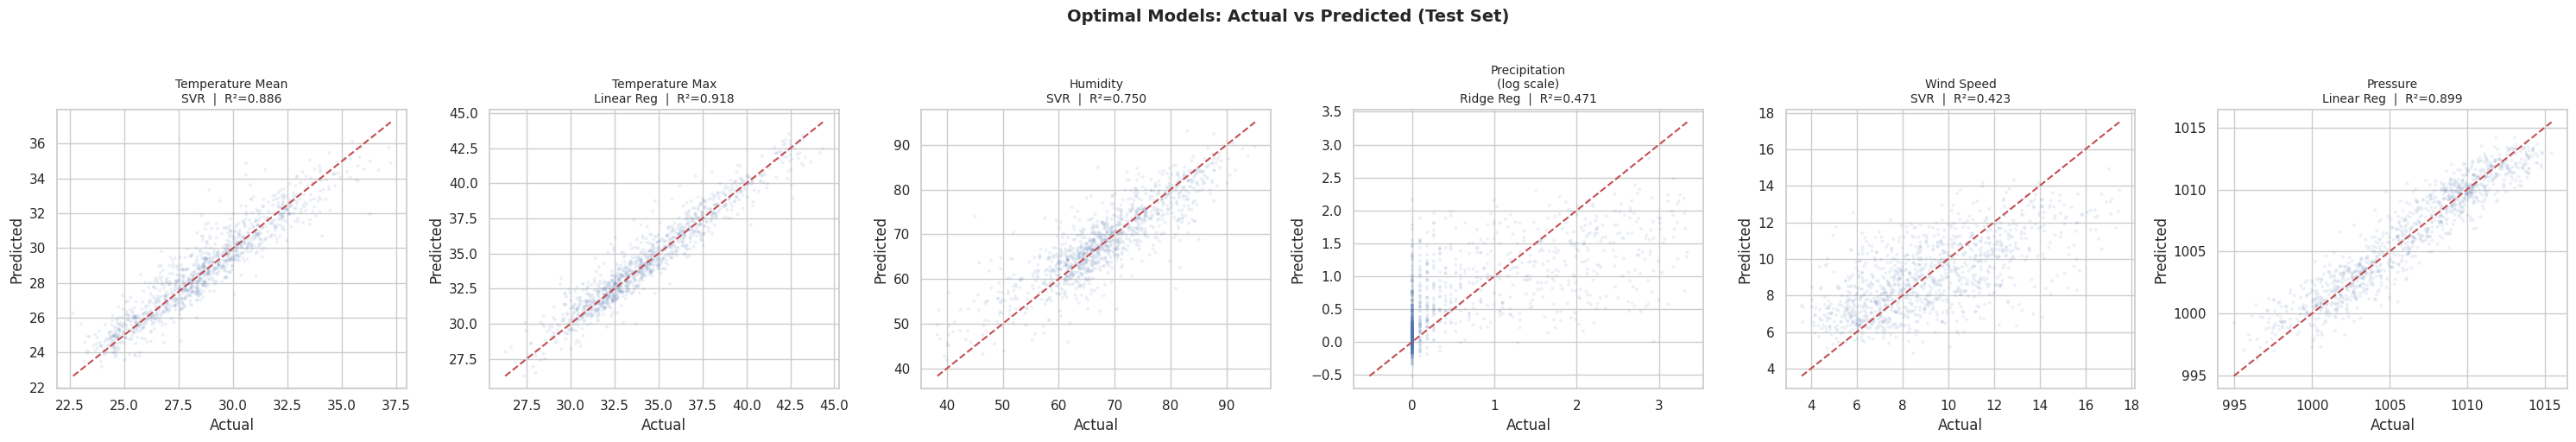

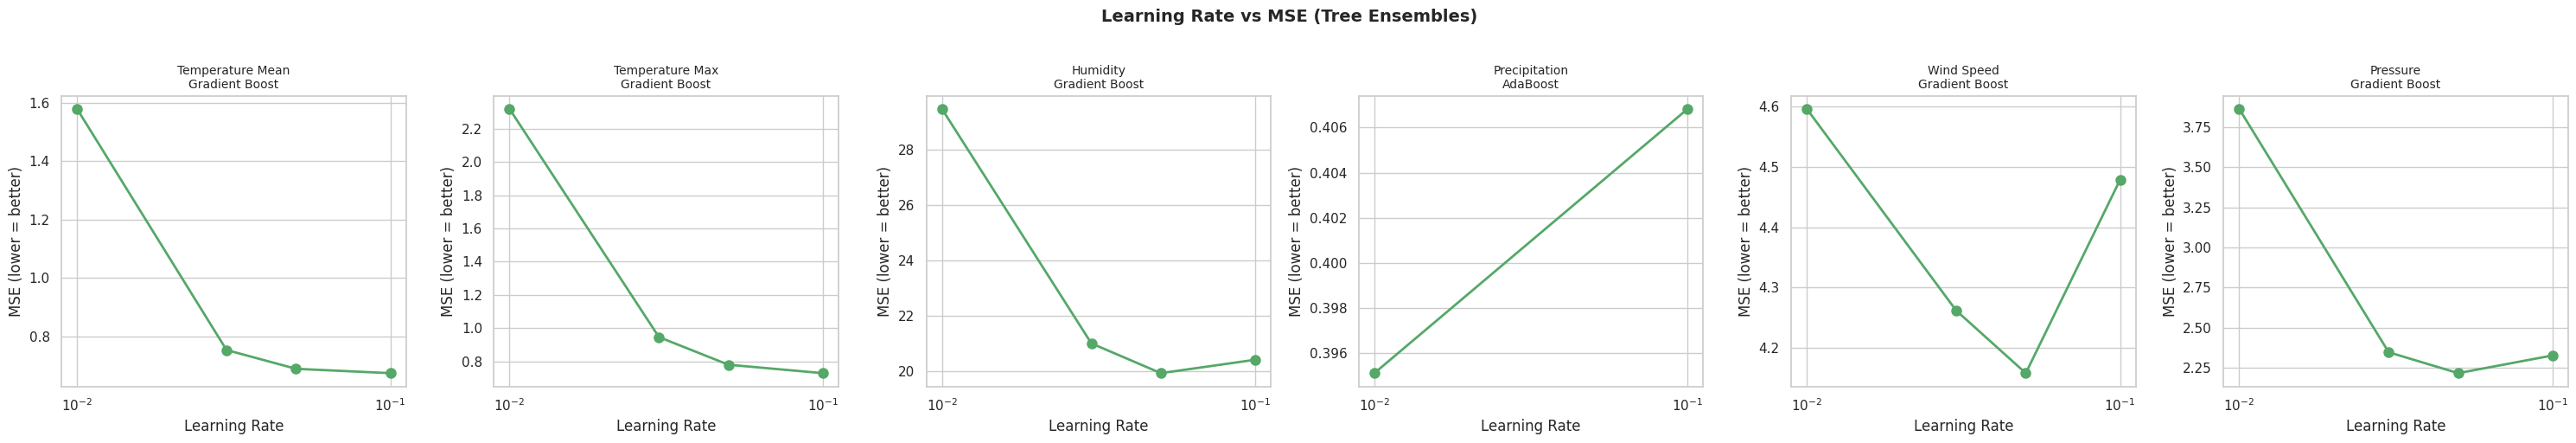

In [ ]:
sns.set_theme(style='whitegrid')

# 1. Actual vs Predicted — note: Precipitation shows log-scale values
n_targets = len(target_mapping)
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5))
fig.suptitle('Optimal Models: Actual vs Predicted (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)

for i, (target_name, target_col) in enumerate(target_mapping.items()):
    y_true   = optimal_predictions[target_col]['y_true']
    y_pred   = optimal_predictions[target_col]['y_pred']
    opt_algo = comparison_reports[target_name].iloc[0]['Algorithm']
    r2       = r2_score(y_true, y_pred)

    ax = axes[i]
    ax.scatter(y_true, y_pred, alpha=0.1, s=8, color='#4C72B0', edgecolors='none')

    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')

    label = target_name
    if target_col == 'precip_log':
        label += '\n(log scale)'
    ax.set_title(f'{label}\n{opt_algo}  |  R²={r2:.3f}', fontsize=10)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

# 2. Learning Rate Effect
fig2, axes2 = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5))
fig2.suptitle('Learning Rate vs MSE (Tree Ensembles)',
              fontsize=14, fontweight='bold', y=1.02)

for i, target_name in enumerate(target_mapping.keys()):
    ax        = axes2[i]
    lr_data   = learning_rate_data.get(target_name, {})
    algo_used = None

    for algo in ['Gradient Boost', 'AdaBoost']:
        if algo in lr_data:
            numeric = {k: v for k, v in lr_data[algo].items() if isinstance(k, (int, float))}
            if len(numeric) > 1:
                algo_used = algo
                sorted_lr = sorted(numeric.keys())
                errors    = [numeric[lr] for lr in sorted_lr]
                ax.plot(sorted_lr, errors, marker='o', color='#55A868', linewidth=2, markersize=8)
                ax.set_xscale('log')
                ax.set_title(f'{target_name}\n{algo}', fontsize=10)
                ax.set_xlabel('Learning Rate')
                ax.set_ylabel('MSE (lower = better)')
                break

    if not algo_used:
        ax.text(0.5, 0.5, 'No numeric LR\ndata available',
                ha='center', va='center', transform=ax.transAxes, color='grey')
        ax.set_title(f'{target_name}\n(No LR data)', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('learning_rate_effect.png', dpi=120, bbox_inches='tight')
plt.show()




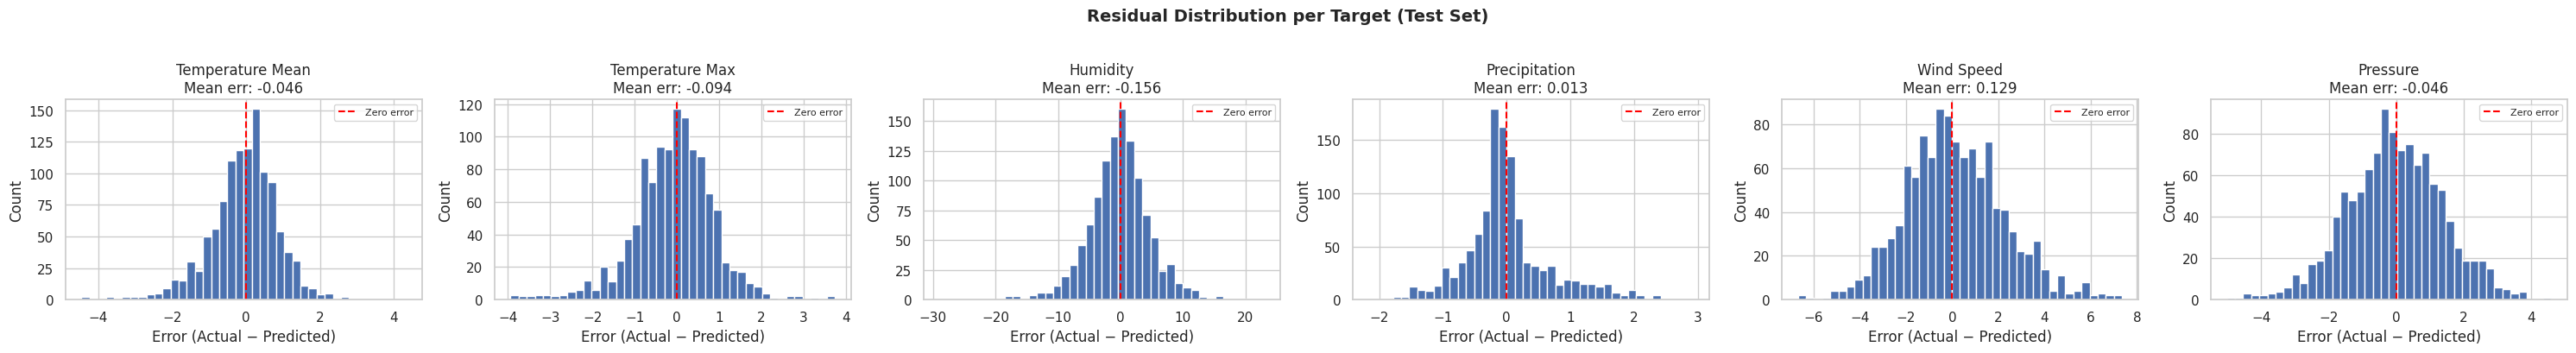

In [ ]:
# ── Residual Distribution (Error Analysis) ──────────────────────────────────
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 4))
fig.suptitle('Residual Distribution per Target (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)

for i, (target_name, target_col) in enumerate(target_mapping.items()):
    y_true    = optimal_predictions[target_col]['y_true']
    y_pred    = optimal_predictions[target_col]['y_pred']
    residuals = y_true - y_pred

    axes[i].hist(residuals, bins=40, color='#4C72B0', edgecolor='white')
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
    axes[i].set_title(f'{target_name}\nMean err: {residuals.mean():.3f}')
    axes[i].set_xlabel('Error (Actual − Predicted)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Predict Today's Weather

---



---



In [ ]:
def predict_today(df, features, scaler, optimal_models, target_mapping):
    df_sorted  = df.sort_values('date')
    latest_row = df_sorted.iloc[-1]
    pred_date  = pd.to_datetime(latest_row['date']) + pd.Timedelta(days=1)

    X_raw  = pd.DataFrame([latest_row[features].to_dict()])
    X_pred = scaler.transform(X_raw)

    print('=' * 50)
    print(f' WEATHER PREDICTION FOR: {pred_date.date()}')
    print('=' * 50)

    # Precipitation: model outputs log1p scale → convert back with expm1
    precip_log_pred = optimal_models['precip_log'].predict(X_pred)[0]
    precip_mm       = np.expm1(max(0, precip_log_pred))
    PRECIP_THRESHOLD = 1.0
    precip_display  = precip_mm if precip_mm >= PRECIP_THRESHOLD else 0.0

    results = {
        'Temperature Mean (°C)':   optimal_models['temp_mean'].predict(X_pred)[0],
        'Temperature Max  (°C)':   optimal_models['temp_max'].predict(X_pred)[0],
        'Humidity         (%)':    optimal_models['humidity_mean'].predict(X_pred)[0],
        'Precipitation    (mm)':   round(precip_display, 2),
        'Wind Speed       (km/h)': max(0, optimal_models['wind_speed_mean'].predict(X_pred)[0]),
        'Pressure         (hPa)':  optimal_models['pressure_mean'].predict(X_pred)[0],
    }

    for label, value in results.items():
        print(f'  {label}: {value:.2f}')
    print('=' * 50)


predict_today(df, features, scaler, optimal_models, target_mapping)

 WEATHER PREDICTION FOR: 2026-04-23
  Temperature Mean (°C): 32.99
  Temperature Max  (°C): 40.36
  Humidity         (%): 58.48
  Precipitation    (mm): 0.00
  Wind Speed       (km/h): 10.61
  Pressure         (hPa): 1004.26
